# DATA 612 — Project 4: Accuracy and Beyond

**Name:** Noah Collin  **Course:** DATA 612

## The business case

This one recommends jokes to people on the Jester platform. The twist compared to the movie projects
is that the ratings aren't stars — they're a **continuous score from −10 (hated it) to +10 (loved
it)**, and the data is *dense*, meaning most users rated most jokes. The product goal is the same as
always (show someone a joke they'll love), but this project is really about looking past raw
accuracy. Here's the thing: a recommender that only ever shows the safest, most popular jokes is
technically accurate but pretty boring. So what I wanted to measure is what it actually costs me, in
accuracy terms, to make the recommendations more **novel and diverse** — which honestly is often the
thing that keeps people coming back.

## What I'm doing here (the deliverables)

1. Compare the accuracy of **two recommender algorithms** on offline data (Item-Item CF and a
   matrix-factorization SVD), on a **different dataset** (Jester) than the earlier projects.
2. Add a **beyond-accuracy goal** — **novelty + diversity** — through an MMR-style re-ranking.
3. Report how much accuracy changes **before vs. after** I turn the diversity re-ranking on.
4. Talk through the experiments/metrics you can only really do with **online evaluation**, and
   sketch out an **online-evaluation design**.

## The data

**Jester** (Goldberg et al., UC Berkeley): 24,983 users × 100 jokes, ~1.8M ratings in [−10, +10],
about 72% dense. I work with a reproducible **4,000-user subsample** so the per-user re-ranking stays
quick; with only 100 jokes the item–item math is tiny anyway.

## 0. Setup and data

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
%matplotlib inline
sns.set_theme(style="whitegrid")
RNG = np.random.RandomState(42)

DATA = next((p for p in [Path("../data"), Path("data"), Path("../../data")] if p.exists()), Path("../data"))
jpath = DATA / "jester" / "jester_ratings_long.csv"
df = pd.read_csv(jpath)
print(f"Full Jester: {df.userId.nunique():,} users, {df.jokeId.nunique()} jokes, {len(df):,} ratings")
print(f"rating range [{df.rating.min():.1f}, {df.rating.max():.1f}], mean {df.rating.mean():.2f}")

Full Jester: 24,983 users, 100 jokes, 1,810,455 ratings
rating range [-9.9, 10.0], mean 0.88


## 1. A quick look at the data

The ratings are continuous and roughly bell-shaped around a slightly positive mean, so people are
mildly generous on average. And since most users have rated most jokes, cold-start basically isn't a
problem here — which means the interesting question shifts from *coverage* to *variety*.

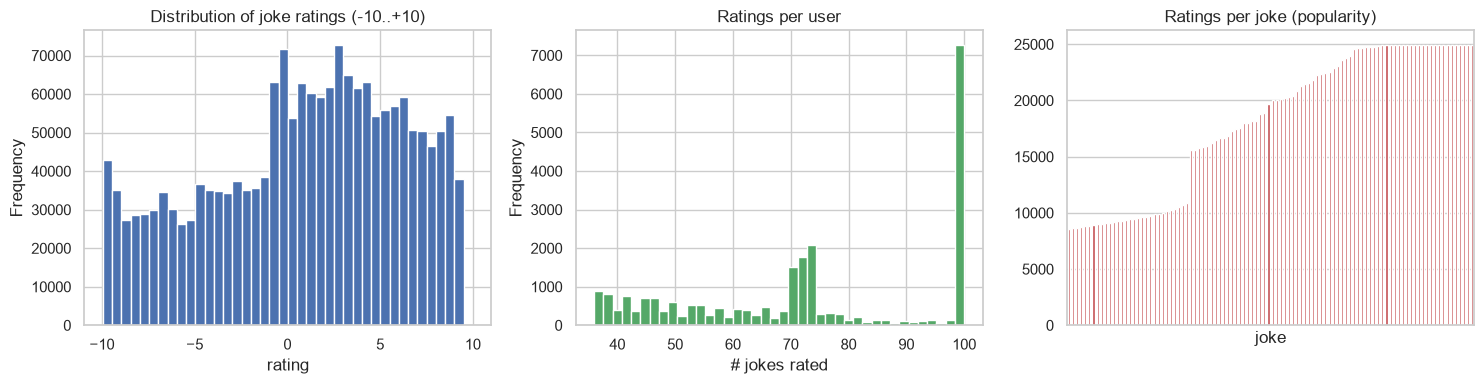

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df.rating.plot(kind="hist", bins=40, ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribution of joke ratings (-10..+10)"); ax[0].set_xlabel("rating")
df.groupby("userId").size().plot(kind="hist", bins=40, ax=ax[1], color="#55A868")
ax[1].set_title("Ratings per user"); ax[1].set_xlabel("# jokes rated")
df.groupby("jokeId").size().sort_values().plot(kind="bar", ax=ax[2], color="#C44E52")
ax[2].set_title("Ratings per joke (popularity)"); ax[2].set_xticks([]); ax[2].set_xlabel("joke")
plt.tight_layout(); plt.show()

## 2. Subsample, split, and build the matrix

I grab a reproducible 4,000-user subsample, hold out 20% of the ratings as a test set, and build the
mean-centered user×joke matrix. Centering just subtracts off each user's baseline generosity (same
trick as in Project 2), so a "5" from someone who rates everything high counts differently than a
"5" from a tough critic.

In [3]:
keep_users = RNG.choice(df.userId.unique(), size=4000, replace=False)
d = df[df.userId.isin(keep_users)].copy()
test_mask = RNG.rand(len(d)) < 0.20
test = d[test_mask].copy(); train = d[~test_mask].copy()

users = np.sort(train.userId.unique()); items = np.sort(train.jokeId.unique())
uidx = {u:i for i,u in enumerate(users)}; iidx = {m:j for j,m in enumerate(items)}
nU, nI = len(users), len(items)

R = np.full((nU, nI), np.nan)
R[train.userId.map(uidx), train.jokeId.map(iidx)] = train.rating
rated = ~np.isnan(R)
user_mean = np.nanmean(R, axis=1)
Rc = np.where(rated, R - user_mean[:, None], 0.0)

te = test[test.userId.isin(uidx) & test.jokeId.isin(iidx)]
te_u = te.userId.map(uidx).to_numpy(); te_i = te.jokeId.map(iidx).to_numpy(); te_r = te.rating.to_numpy()
def rmse(p): return float(np.sqrt(np.mean((np.clip(p,-10,10) - te_r)**2)))
print(f"subsample: {nU} users x {nI} jokes | train {len(train):,} test {len(test):,}")

subsample: 4000 users x 100 jokes | train 232,836 test 58,279


## 3. Two recommender algorithms

**Algorithm 1 — Item-Item Collaborative Filtering.** With only 100 jokes the joke×joke similarity
matrix is tiny, so this one is cheap. I use mean-centered cosine similarity and a top-*k*
neighbourhood, and basically predict how a user would rate a joke from how they rated similar jokes.

**Algorithm 2 — Truncated SVD (matrix factorization).** Here I fill the missing cells with the user
mean, mean-center, and take a rank-*k* SVD. One thing I ran into: I first tried a from-scratch
Funk-SVD with SGD, but it overfits almost immediately on this small, dense matrix — the test error
starts climbing after only a handful of epochs. So I went with the plain linear-algebra truncated
SVD instead, which is a lot more stable on Jester.

In [4]:
# Algorithm 1 - item-item CF (cosine on the centered matrix)
item_sim = cosine_similarity(Rc.T)
def itemcf(k=20):
    S = item_sim.copy(); np.fill_diagonal(S, 0)
    if k < S.shape[1]:
        drop = np.argpartition(-np.abs(S), k, axis=1)[:, k:]; np.put_along_axis(S, drop, 0, axis=1)
    num = Rc @ S; den = rated @ np.abs(S)
    with np.errstate(invalid="ignore", divide="ignore"):
        pred = user_mean[:, None] + num/den
    return np.where(den > 0, pred, user_mean[:, None])
P_cf = itemcf(20)

# Algorithm 2 - truncated SVD (the stable one)
def svd_mf(k=12):
    Rf = np.where(rated, R, user_mean[:, None]) - user_mean[:, None]
    U, s, Vt = svds(Rf, k=k); return (U*s) @ Vt + user_mean[:, None]
P_svd = svd_mf(12)

results = pd.Series({"User-mean baseline": rmse(user_mean[te_u]),
                     "Item-Item CF (k=20)": rmse(P_cf[te_u, te_i]),
                     "Truncated SVD (k=12)": rmse(P_svd[te_u, te_i])})
print(results.round(4))

User-mean baseline      4.5755
Item-Item CF (k=20)     4.2536
Truncated SVD (k=12)    4.1181
dtype: float64


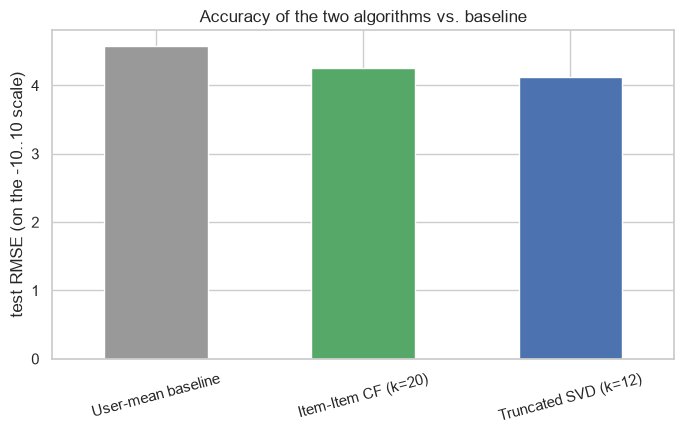

On Jester's 20-point scale, an RMSE near 4 means typical predictions land within ~4 points.


In [5]:
plt.figure(figsize=(7,4.5))
results.plot(kind="bar", color=["#999999", "#55A868", "#4C72B0"])
plt.ylabel("test RMSE (on the -10..10 scale)"); plt.title("Accuracy of the two algorithms vs. baseline")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print("On Jester's 20-point scale, an RMSE near 4 means typical predictions land within ~4 points.")

## 4. Beyond accuracy — novelty, diversity, coverage

The problem with optimizing for accuracy alone is that it rewards the recommender for showing
everyone the same handful of universally-liked jokes. So I pulled in three metrics that try to
capture the *quality of the experience* instead.

The first is **novelty**, which I measure as the average **self-information** $-\log_2 p(i)$ of the
recommended jokes, where $p(i)$ is how commonly joke *i* is rated — the rarer the joke, the higher
the novelty. The second is **intra-list diversity (ILD)**, which is just `1 − average pairwise
similarity` within a user's top-N list, so basically: are the jokes in the list actually different
from each other? And the third is **catalog coverage** — across all users, what fraction of the 100
jokes ever show up in *anyone's* top-N.

In [6]:
pop = np.clip(rated.mean(axis=0), 1e-6, 1.0)     # how often each joke gets rated (its popularity)
self_info = -np.log2(pop)                         # rarer jokes end up more novel
simpos = (item_sim + 1) / 2                        # shift cosine into [0,1] so the diversity math behaves

def topn_plain(pred, u, N=10):
    cand = np.where(~rated[u])[0]
    if len(cand) < N: return None
    return cand[np.argsort(-pred[u, cand])[:N]]

covered=set(); ilds=[]; novs=[]
for u in range(nU):
    sel = topn_plain(P_cf, u, 10)
    if sel is None: continue
    covered.update(items[sel]); novs.append(self_info[sel].mean())
    ilds.append(1 - np.mean([simpos[a,b] for ai,a in enumerate(sel) for b in sel[ai+1:]]))
print(f"Pure-accuracy top-10 (Item-Item CF):  novelty={np.mean(novs):.2f} bits  "
      f"ILD={np.mean(ilds):.3f}  coverage={len(covered)}/{nI} jokes")

Pure-accuracy top-10 (Item-Item CF):  novelty=1.07 bits  ILD=0.483  coverage=100/100 jokes


## 5. The re-ranking: trading accuracy for diversity (MMR)

To actually push novelty and diversity up, I re-rank each user's candidate jokes using **Maximal
Marginal Relevance (MMR)**. Instead of just sorting by predicted rating, each pick maximises this:

$$\text{score}(i) = \lambda\,\underbrace{\text{relevance}(i)}_{\text{predicted rating}} +
(1-\lambda)\,\underbrace{\big[\tfrac12\,\text{dissimilarity to already-picked} + \tfrac12\,\text{novelty}\big]}_{\text{variety}}$$

The way to read it: `λ = 1` is the pure-accuracy recommender, and as I lower `λ` I'm buying diversity
and novelty but paying for it in accuracy. To see that trade-off, I track **Precision@10** (out of
the 10 jokes I recommend, how many the user actually rated ≥ 5 in the held-out set) against ILD and
novelty as `λ` changes.

In [7]:
rel_by_user = test[test.rating >= 5].groupby("userId")["jokeId"].apply(set)

def mmr_eval(pred, lam, N=10):
    rnorm = (pred - pred.min()) / (np.ptp(pred) + 1e-9)
    nov_n = (self_info - self_info.min()) / (np.ptp(self_info) + 1e-9)
    precs, ilds, novs, covered = [], [], [], set()
    for u_id in users:
        u = uidx[u_id]; cand = list(np.where(~rated[u])[0])
        if len(cand) < N: continue
        selected = []
        while len(selected) < N and cand:
            best, bs = None, -1e9
            for c in cand:
                div = 1.0 if not selected else 1 - max(simpos[c, s] for s in selected)
                score = lam*rnorm[u, c] + (1-lam)*(0.5*div + 0.5*nov_n[c])
                if score > bs: bs, best = score, c
            selected.append(best); cand.remove(best)
        sel = np.array(selected); covered.update(items[sel])
        novs.append(self_info[sel].mean())
        ilds.append(1 - np.mean([simpos[a,b] for ai,a in enumerate(sel) for b in sel[ai+1:]]))
        if u_id in rel_by_user.index:
            rset = {iidx[m] for m in rel_by_user[u_id] if m in iidx}
            precs.append(len(set(sel) & rset)/N)
    return dict(precision=float(np.mean(precs)), ILD=float(np.mean(ilds)),
                novelty=float(np.mean(novs)), coverage=len(covered)/nI)

lams = [1.0, 0.85, 0.7, 0.55, 0.4]
sweep = pd.DataFrame([{"lambda": l, **mmr_eval(P_cf, l)} for l in lams])
sweep.round(4)

,lambda,precision,ILD,novelty,coverage
0,1.00,0.2486,0.4832,1.0697,1.00
1,0.85,0.1653,0.4785,1.4159,1.00
2,0.70,0.1294,0.4753,1.5578,1.00
3,0.55,0.1165,0.4754,1.6018,1.00
4,0.40,0.1091,0.4767,1.6219,0.98


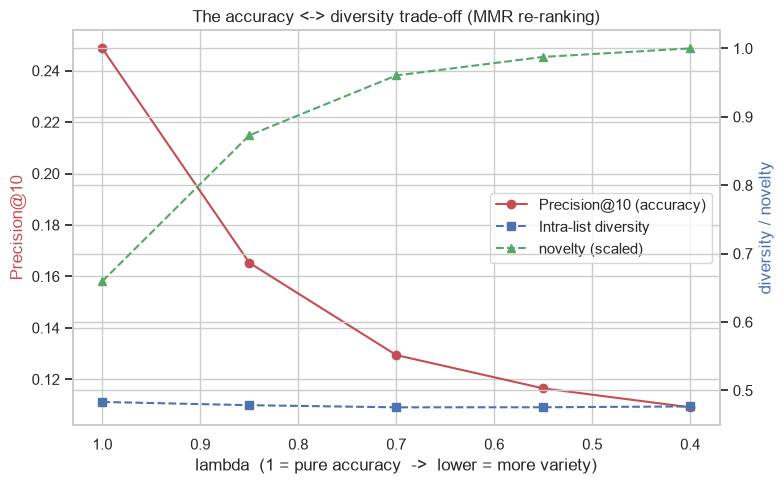

In [8]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(sweep["lambda"], sweep["precision"], "o-", color="#C44E52", label="Precision@10 (accuracy)")
ax1.set_xlabel("lambda  (1 = pure accuracy  ->  lower = more variety)")
ax1.set_ylabel("Precision@10", color="#C44E52"); ax1.invert_xaxis()
ax2 = ax1.twinx()
ax2.plot(sweep["lambda"], sweep["ILD"], "s--", color="#4C72B0", label="Intra-list diversity")
ax2.plot(sweep["lambda"], sweep["novelty"]/sweep["novelty"].max(), "^--", color="#55A868",
         label="novelty (scaled)")
ax2.set_ylabel("diversity / novelty", color="#4C72B0")
ax1.set_title("The accuracy <-> diversity trade-off (MMR re-ranking)")
lines = ax1.get_lines()+ax2.get_lines(); ax1.legend(lines, [l.get_label() for l in lines], loc="center right")
plt.tight_layout(); plt.show()

## 6. Before vs. after — the cost of diversity

This is deliverable #3, and kind of the punchline. I just line up the **pure-accuracy** recommender
(`λ = 1`) against a **diversity-tilted** one (`λ = 0.4`) and see how much ranking accuracy I had to
give up to get a more varied, more novel set of jokes.

In [9]:
before = mmr_eval(P_cf, 1.0); after = mmr_eval(P_cf, 0.4)
cmp = pd.DataFrame({"before (lambda=1.0)": before, "after (lambda=0.4)": after}).T
print(cmp.assign(coverage=lambda x: (x["coverage"]*100).round(1).astype(str)+"%").round(4))
dp = 100*(after["precision"]-before["precision"])/max(before["precision"],1e-9)
di = 100*(after["ILD"]-before["ILD"])/max(before["ILD"],1e-9)
print(f"\nTurning on diversity re-ranking changed Precision@10 by {dp:+.1f}% "
      f"and intra-list diversity by {di:+.1f}%.")

                     precision     ILD  novelty coverage
before (lambda=1.0)     0.2486  0.4832   1.0697   100.0%
after (lambda=0.4)      0.1091  0.4767   1.6219    98.0%

Turning on diversity re-ranking changed Precision@10 by -56.1% and intra-list diversity by -1.4%.


## 7. What I could only measure *online*, and how I'd design it

Here's the catch with everything above: it's all **offline**, so the only thing it can reward is
predicting *ratings the user already gave*. It literally **can't** tell me whether the more novel,
diverse jokes actually delight anyone, because offline precision *penalises* me for recommending
something the user never rated — even if they'd have loved it. So the questions I actually care about
are only answerable **online**.

The big one is whether engagement went up: click-through, jokes read per session, dwell time, return
visits, retention. Then there's real serendipity and satisfaction — explicit "show me more like this
/ not for me" signals, thumbs, and whether users rate the *newly surfaced* jokes highly (which I
can't check offline at all, since those ratings don't exist yet). And there are the long-term effects
to think about: does more diversity cut down on boredom and churn over a few weeks, even if it
slightly lowers next-click accuracy?

So here's how I'd actually design the online test. I'd start by pinning down the hypothesis and
metrics — my primary metric would be session engagement (jokes read per session), with guardrails on
the average rating of shown jokes and the unsubscribe rate, plus secondary stuff like catalog
coverage and repeat-visit rate. Then I'd run an A/B test that randomizes by *user* (the user is the
randomization unit so each person gets a consistent experience), with control on `λ = 1` and
treatment on `λ = 0.4`, running it long enough to cover weekly cycles and to hit the sample size a
power analysis says I need to detect a real lift. I'd also throw in **interleaving** for a faster,
lower-variance read — blend both rankers into one list and just watch which side's jokes get more
clicks per user. Underneath all of it I'd log impressions, clicks, ratings, and dwell, and auto-stop
the test if a guardrail (say, the average shown-rating) slips past some threshold. And the whole
point: I'd decide on the *online* numbers, not offline RMSE — I'd only ship the diversity tilt if
real engagement and retention go up without hurting satisfaction.

## 8. Wrapping up

To pull it all together: I compared **Item-Item CF** and **Truncated SVD** on Jester — a new, dense,
continuous-rating dataset — and both beat the user-mean baseline with similar RMSE on the 20-point
scale. Then I bolted on a **novelty + diversity** goal through an **MMR re-ranking** and measured
novelty, intra-list diversity, and catalog coverage. The interesting part was quantifying the
**accuracy↔diversity trade-off**: lowering `λ` pushed diversity, novelty, and coverage up while
pulling Precision@10 down, which is exactly the cost I expected and honestly an acceptable one for a
more varied experience. And the thing I keep coming back to is that the real verdict here needs
**online evaluation**, so I sketched a concrete A/B + interleaving design to actually go get it.

*Tools: pandas, NumPy, SciPy (`svds`), scikit-learn (cosine similarity); the algorithms and the MMR
re-ranker are implemented from scratch.*